# High-Value Fleet Analysis
**Core Pattern:** Scan, Filter, & Project

Long-distance, high-fare trips with sanity bounds. Each engine returns its native materialized result; DuckDB materializes into a session-scoped temp table instead of exporting to Arrow. Polars is run in default and streaming mode; DuckDB is run default and internally memory-capped.


In [1]:
import sys, os

try:
    import datapunk  # noqa: F401
except ImportError:
    sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "src")))

os.environ["DAFT_PROGRESS_BAR"] = "0"
import plotly.io as pio

pio.renderers.default = "svg"

from datapunk.reporter import DatapunkReporter

RAM_CAP = 1024  # in MB

reporter = DatapunkReporter(
    small_months=1,
    large_cap_mb=RAM_CAP,
    with_lookup=False,
)

  ⚙ unifying schema across 24 files (20 cols)…
     ✅ unified files cached.


Datapunk Environment
----------------------------------------------------
  OS:        Darwin 25.3.0
  CPU:       Apple M1 Pro (8 cores)
  RAM:       16.0 GB
  Python:    v3.14.6
  Small run: 1 month, uncapped
  Large run: 24 months, cap = 1024 MB (physical RSS)
----------------------------------------------------


## Analytics Functions

In [2]:
# Long-distance, high-fare trips with sanity bounds (raw TLC carries GPS/meter noise).
COLS = ["trip_distance", "passenger_count", "fare_amount", "total_amount"]
PARQUET_FILTERS = [
    [
        ("trip_distance", ">", 10.0),
        ("trip_distance", "<", 100.0),
        ("fare_amount", ">", 40.0),
        ("fare_amount", "<", 500.0),
        ("total_amount", ">", 0.0),
    ]
]


def scan_filter_pandas(file_path):
    import pandas as pd

    df = pd.concat(
        [pd.read_parquet(p, columns=COLS) for p in file_path],
        ignore_index=True,
    )
    mask = (
        (df["trip_distance"] > 10.0)
        & (df["trip_distance"] < 100.0)
        & (df["fare_amount"] > 40.0)
        & (df["fare_amount"] < 500.0)
        & (df["total_amount"] > 0.0)
    )
    result = df.loc[mask, COLS].copy()  # eager, pandas-native materialized output
    return result, {"engine": pd.__name__, "version": pd.__version__}


def scan_filter_polars(file_path):
    import polars as pl

    lf = (
        pl.scan_parquet(file_path)
        .filter(
            (pl.col("trip_distance") > 10.0)
            & (pl.col("trip_distance") < 100.0)
            & (pl.col("fare_amount") > 40.0)
            & (pl.col("fare_amount") < 500.0)
            & (pl.col("total_amount") > 0.0)
        )
        .select(COLS)
    )
    result = lf.collect()  # eager, Polars-native materialized output
    return result, {"engine": pl.__name__, "version": pl.__version__}


def scan_filter_polars_streaming(file_path):
    import polars as pl

    lf = (
        pl.scan_parquet(file_path)
        .filter(
            (pl.col("trip_distance") > 10.0)
            & (pl.col("trip_distance") < 100.0)
            & (pl.col("fare_amount") > 40.0)
            & (pl.col("fare_amount") < 500.0)
            & (pl.col("total_amount") > 0.0)
        )
        .select(COLS)
    )
    result = lf.collect(engine="streaming")  # still returns an eager Polars DataFrame
    return result, {"engine": f"{pl.__name__}-streaming", "version": pl.__version__}


def _duckdb_materialize(file_path, *, capped=False):
    import duckdb
    import uuid
    from datapunk.fingerprint import DuckDBTableResult

    con = duckdb.connect()
    if capped:
        con.execute(f"SET memory_limit='{int(RAM_CAP * 0.8)}MB'")

    table = f"datapunk_result_{uuid.uuid4().hex}"
    con.execute(
        f"""
        CREATE TEMP TABLE {table} AS
        SELECT trip_distance, passenger_count, fare_amount, total_amount
        FROM read_parquet($files)
        WHERE trip_distance > 10.0 AND trip_distance < 100.0
          AND fare_amount > 40.0 AND fare_amount < 500.0 AND total_amount > 0.0
        """,
        {"files": list(map(str, file_path))},
    )
    return DuckDBTableResult(con=con, table=table)


def scan_filter_duckdb(file_path):
    import duckdb

    result = _duckdb_materialize(file_path, capped=False)
    return result, {"engine": duckdb.__name__, "version": duckdb.__version__}


def scan_filter_duckdb_capped(file_path):
    import duckdb

    result = _duckdb_materialize(file_path, capped=True)
    return result, {
        "engine": f"{duckdb.__name__}-capped",
        "version": duckdb.__version__,
    }


def scan_filter_dask(file_path):
    import dask
    import dask.dataframe as dd

    df = dd.read_parquet(file_path, columns=COLS, filters=PARQUET_FILTERS)
    result = df[
        (df["trip_distance"] > 10.0)
        & (df["trip_distance"] < 100.0)
        & (df["fare_amount"] > 40.0)
        & (df["fare_amount"] < 500.0)
        & (df["total_amount"] > 0.0)
    ][COLS].compute()  # eager, pandas-native materialized output
    return result, {"engine": dask.__name__, "version": dask.__version__}


def scan_filter_daft(file_path):
    import daft

    df = daft.read_parquet(file_path)
    result = (
        df.filter(
            (df["trip_distance"] > 10.0)
            & (df["trip_distance"] < 100.0)
            & (df["fare_amount"] > 40.0)
            & (df["fare_amount"] < 500.0)
            & (df["total_amount"] > 0.0)
        )
        .select(*COLS)
        .collect()  # eager, Daft-native materialized output
    )
    return result, {"engine": daft.__name__, "version": daft.__version__}


ANALYTICS = [
    scan_filter_pandas,
    scan_filter_polars,
    scan_filter_polars_streaming,
    scan_filter_duckdb,
    scan_filter_duckdb_capped,
    scan_filter_dask,
    scan_filter_daft,
]

## Execution & Verification

In [3]:
reporter.run_all(
    ANALYTICS,
    target_cols=["trip_distance", "passenger_count", "fare_amount", "total_amount"],
)
reporter.export_results(
    suite_id="01",
    title="High-Value Fleet Analysis",
    core_pattern="Scan, Filter, & Project",
    description="Long-distance, high-fare trips with sanity bounds. Polars: default vs. streaming. DuckDB: default vs. memory-capped.",
)


▶ SMALL run (1 month, cap=none)


    pandas v3.0.3               35 ms  peak 460 MB


    polars v1.41.2              13 ms  peak 258 MB


    polars-streaming v1.41.2      13 ms  peak 256 MB


    duckdb v1.5.4               36 ms  peak 169 MB


...

    polars-streaming v1.41.2     193 ms  peak 888 MB


    duckdb v1.5.4              394 ms  peak 948 MB


    duckdb-capped v1.5.4       413 ms  peak 948 MB


    dask v2026.6.0                OOM  peak 1041 MB


    daft v0.7.15               549 ms  peak 721 MB
    → consistency: ✅ 5 engine(s) agree (6,468,548 rows)
📊 exported suite [01] → public/benchmark_results.json


## Analysis

Fare structure of long-distance trips. The heatmap shows where distance and price concentrate — most long trips cluster in the \$50–\$150 range.

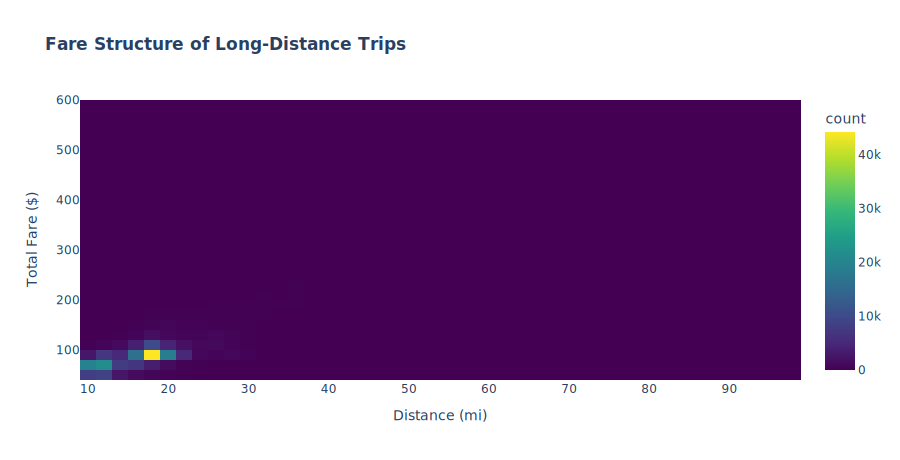

In [4]:
import plotly.express as px

# Visualization is intentionally standardized through pandas on the small run.
reporter.set_analysis_fn(scan_filter_pandas, mode="small")
df = reporter.get_analysis_df(["trip_distance", "total_amount"])
fig = px.density_heatmap(
    df,
    x="trip_distance",
    y="total_amount",
    nbinsx=45,
    nbinsy=45,
    color_continuous_scale="Viridis",
    title="<b>Fare Structure of Long-Distance Trips</b>",
    labels={"trip_distance": "Distance (mi)", "total_amount": "Total Fare ($)"},
)
fig.update_layout(template="plotly_white", width=900, height=460)
fig.show()

## Performance Comparison

In [5]:
reporter.show_scorecard("Scan & Filter Performance")

#### Scan & Filter Performance — Single Month · Uncapped

| Engine                   | Time    | Velocity   | Peak RAM   | Stress   |
|:-------------------------|:--------|:-----------|:-----------|:---------|
| pandas v3.0.3            | 0.0345s | 1.2×       | 460 MB     | —        |
| daft v0.7.15             | 0.0395s | 1.0×       | 150 MB     | —        |
| dask v2026.6.0           | 0.0407s | 1.0×       | 360 MB     | —        |
| duckdb v1.5.4            | 0.0362s | 1.1×       | 169 MB     | —        |
| duckdb-capped v1.5.4     | 0.0364s | 1.1×       | 164 MB     | —        |
| polars v1.41.2           | 0.0134s | 3.0×       | 258 MB     | —        |
| polars-streaming v1.41.2 | 0.0132s | **3.1×**   | 256 MB     | —        |

*✅ 7 engine(s) agree (220,200 rows)*

#### Scan & Filter Performance — Full Window · 1024 MB Cap

| Engine                   | Time    | Velocity   | Peak RAM   | Stress   |
|:-------------------------|:--------|:-----------|:-----------|:---------|
| pandas v3.0.3            | **OOM** | —          | ≥1038 MB   | ≥1.01    |
| daft v0.7.15             | 0.5495s | 1.0×       | 721 MB     | 0.70     |
| dask v2026.6.0           | **OOM** | —          | ≥1041 MB   | ≥1.02    |
| duckdb v1.5.4            | 0.3944s | 1.4×       | 948 MB     | 0.93     |
| duckdb-capped v1.5.4     | 0.4126s | 1.3×       | 948 MB     | 0.93     |
| polars v1.41.2           | 0.2005s | 2.7×       | 897 MB     | 0.88     |
| polars-streaming v1.41.2 | 0.1934s | **2.8×**   | 888 MB     | 0.87     |

*✅ 5 engine(s) agree (6,468,548 rows)*